# Think-LIBERO + caution inject + five drift probes

One checkpoint: `allenai/MolmoAct2-Think-LIBERO`. Kernel **molmoact2**. Not Molmo2-ER.

The extra sentence is spliced into the official `The task is to {task}` slot. `normalize_language=False` so punctuation survives.

Below the original run: **five probes**, drifting further from the official system. None of them use `predict_action`. 1–3 rebuild the vendor's exact robot prompt (verified against `vendor/molmoact2` source) with the forced `<depth_output><action_output>` trigger stripped — free continuation, plus a `[START ACTION]` sentinel contract where the harness re-attaches the trigger once the model has spoken. 4–5 are plain chat `generate` on the same Think weights — probe 4 with the agentview image, probe 5 text-only ("hello there", no image).

Depth/action **payload** tokens (`<depth_12>`, `<action_3>`, …) render as `█`. Brackets (`<depth_start>`, `<depth_end>`, `<action_output>`, …) stay. Continuous actions are vectors, not tokens — they only appear in the last pane.

If `screenshot/` is empty: `source .venv/bin/activate && python download_frames.py`

task (injected):
put the white mug on the left plate and put the yellow and white mug on the right plate. if an instruction is unclear, ask a follow-up before committing; keep the arm still until you are certain


**What it sees** (Think-LIBERO card, libero_10 / ep0 / t0)

agentview `sample_agentview_rgb.png` (256, 256)

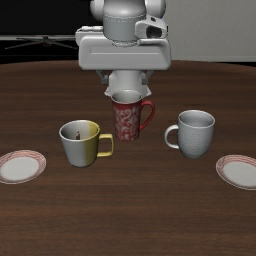

wrist `sample_wrist_rgb.png` (256, 256)

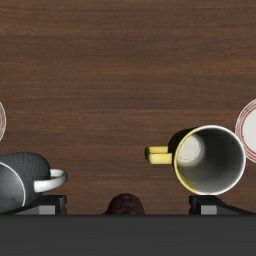

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from IPython.display import display, Markdown
from PIL import Image
from think_act import (
    INJECT,
    OFFICIAL_TASK,
    ThinkLibero,
    composed_task,
)

SHOT = ROOT / "screenshot"
third_p = SHOT / "sample_agentview_rgb.png"
wrist_p = SHOT / "sample_wrist_rgb.png"
if not third_p.is_file() or not wrist_p.is_file():
    raise FileNotFoundError(
        "screenshot/ missing official frames. In the molmoact2 venv: python download_frames.py"
    )
third = Image.open(third_p).convert("RGB")
wrist = Image.open(wrist_p).convert("RGB")
task = composed_task(OFFICIAL_TASK, INJECT)
print("task (injected):")
print(task)
display(Markdown("**What it sees** (Think-LIBERO card, libero_10 / ep0 / t0)"))
display(Markdown(f"agentview `{third_p.name}` {third.size}"))
display(third)
display(Markdown(f"wrist `{wrist_p.name}` {wrist.size}"))
display(wrist)

## Load + `predict_action`

Restart the kernel if you already have Think or Molmo2-ER in VRAM.

In [2]:
thinker = ThinkLibero()
out = thinker.act(third, wrist, inject=INJECT, normalize_language=False)
print("normalize_language", out["normalize_language"])
print("n tokens", len(out["token_ids"]))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

normalize_language False
n tokens 102


## Full output text

`generated_token_ids` decoded with specials kept. Empty here means the card did not return ids.

In [3]:
print(out["full_text"] or "(no generated_token_ids)")

<depth_start><depth_9><depth_9><depth_55><depth_8><depth_101><depth_32><depth_75><depth_55><depth_116><depth_28><depth_55><depth_9><depth_28><depth_30><depth_101><depth_101><depth_69><depth_55><depth_74><depth_55><depth_55><depth_74><depth_9><depth_75><depth_32><depth_56><depth_32><depth_74><depth_74><depth_55><depth_101><depth_8><depth_116><depth_8><depth_69><depth_8><depth_9><depth_9><depth_32><depth_69><depth_56><depth_8><depth_69><depth_25><depth_101><depth_8><depth_9><depth_56><depth_8><depth_8><depth_101><depth_32><depth_101><depth_56><depth_32><depth_69><depth_32><depth_75><depth_8><depth_8><depth_75><depth_32><depth_56><depth_56><depth_69><depth_8><depth_8><depth_32><depth_32><depth_32><depth_75><depth_101><depth_32><depth_32><depth_56><depth_56><depth_32><depth_56><depth_56><depth_56><depth_26><depth_75><depth_26><depth_75><depth_75><depth_75><depth_75><depth_75><depth_75><depth_75><depth_74><depth_55><depth_74><depth_74><depth_74><depth_74><depth_74><depth_74><depth_74><depth

## Tokenized → English

`█` = a depth/action/state **value** token. Brackets stay as names.

In [4]:
print(out["boxed"] or "(no generated_token_ids)")
print("--- token names ---")
for i, (tid, name) in enumerate(zip(out["token_ids"], out["token_names"])):
    print(f"{i:4d}  {tid:6d}  {name}")

<depth_start>████████████████████████████████████████████████████████████████████████████████████████████████████<depth_end>
--- token names ---
   0  153983  <depth_start>
   1  153994  <depth_9>
   2  153994  <depth_9>
   3  154040  <depth_55>
   4  153993  <depth_8>
   5  154086  <depth_101>
   6  154017  <depth_32>
   7  154060  <depth_75>
   8  154040  <depth_55>
   9  154101  <depth_116>
  10  154013  <depth_28>
  11  154040  <depth_55>
  12  153994  <depth_9>
  13  154013  <depth_28>
  14  154015  <depth_30>
  15  154086  <depth_101>
  16  154086  <depth_101>
  17  154054  <depth_69>
  18  154040  <depth_55>
  19  154059  <depth_74>
  20  154040  <depth_55>
  21  154040  <depth_55>
  22  154059  <depth_74>
  23  153994  <depth_9>
  24  154060  <depth_75>
  25  154017  <depth_32>
  26  154041  <depth_56>
  27  154017  <depth_32>
  28  154059  <depth_74>
  29  154059  <depth_74>
  30  154040  <depth_55>
  31  154086  <depth_101>
  32  153993  <depth_8>
  33  154101  <depth_116>
  

## Depth bins + actions

These are the numeric outputs (10×10 depth codes, then the 10-step EEF chunk). Not spliced into the sentence.

In [5]:
print("depth_bins")
print(out["depth_bins"])
print("updated_cells")
print(out.get("updated_cells"))
print("actions")
print(out["actions"])

depth_bins
tensor([[  9,   9,  55,   8, 101,  32,  75,  55, 116,  28,  55,   9,  28,  30,
         101, 101,  69,  55,  74,  55,  55,  74,   9,  75,  32,  56,  32,  74,
          74,  55, 101,   8, 116,   8,  69,   8,   9,   9,  32,  69,  56,   8,
          69,  25, 101,   8,   9,  56,   8,   8, 101,  32, 101,  56,  32,  69,
          32,  75,   8,   8,  75,  32,  56,  56,  69,   8,   8,  32,  32,  32,
          75, 101,  32,  32,  56,  56,  32,  56,  56,  56,  26,  75,  26,  75,
          75,  75,  75,  75,  75,  75,  74,  55,  74,  74,  74,  74,  74,  74,
          74,  28]], device='cuda:0')
updated_cells
None
actions
tensor([[[ 1.1658e-02, -5.1758e-02, -1.5991e-02, -9.6512e-04, -4.3335e-03,
          -3.5706e-03, -9.9219e-01],
         [ 3.7689e-03, -6.5430e-02, -1.9897e-02, -1.6479e-03, -4.2419e-03,
          -2.7008e-03, -9.8828e-01],
         [ 4.1504e-03, -8.3008e-02, -1.9653e-02, -1.4191e-03, -3.6774e-03,
          -2.9297e-03, -9.9219e-01],
         [-3.4523e-04, -1.1816e-01,

## Five drift probes — all off `predict_action`

Checked against the vendor source (clone in `vendor/molmoact2`, gitignored; `experiments/olmo/hf_model/modeling_molmoact2.py`). Facts, not guesses:

- The official prompt is a **raw string**, not a chat template: `Image 1<|image|>Image 2<|image|><|im_start|>user\n{prompt}<|im_end|>\n<|im_start|>assistant\n<depth_output><action_output>` — the muzzle is those last two tokens, baked into the text before generation starts.
- `{prompt}` = `The task is to {task}. The setup is <setup_start>…<setup_end>. The current state of the robot is <state_…>. The expected control mode is <control_start>…<control_end>. Given these, first predict the depth map of the main image and then predict the action the robot should take to complete the task?`
- `normalize_language=True` would lowercase and strip our punctuation (`_normalize_question_text`); we bypass it entirely.

Probes 1–3 rebuild that exact user turn via the model's **own runtime module** (same code, loaded from the weights dir), **strip the trigger**, and generate free:

1. Official task, free continuation — does the model muzzle itself?
2. Clear task + sentinel contract — English sentence first, then `[START ACTION]`; on sentinel, the harness tacks on `<depth_output><action_output>` and continues.
3. Ambiguous task — clarifying question, or the sentinel if it thinks it knows.

Probes 4–5 (chat `generate`, image / no image) unchanged — that call shape is the vendor's own docstring example.

Each probe prints the **raw decode first** (specials kept), with blank space between the before-sentinel and after-sentinel panes. Formatted (boxed / residue / depth counts) comes after.

**Caveat:** inside `predict_action`, depth decoding is *constrained* (`_generate_depth_prefix`) and continuous actions come from the flow expert. Free generation shows text-side transitions only — no arm-motion numbers in probes 1–3.

In [6]:
import re
import sys
import numpy as np
import torch
from think_act import OFFICIAL_STATE, append_log, format_generated

SENTINEL = "[START ACTION]"


def raw_decode(gen_ids) -> str:
    tok = thinker.processor.tokenizer
    ids = gen_ids.tolist() if hasattr(gen_ids, "tolist") else list(gen_ids)
    if not ids:
        return ""
    return tok.decode(ids, skip_special_tokens=False, clean_up_tokenization_spaces=False)


def show_raw(title: str, text: str) -> None:
    """Loud header + the verbatim decode + blank lines so panes don't run together."""
    display(Markdown(f"### {title}"))
    print()
    print(text if text else "(empty)")
    print()
    print()
    print()


def english_residue(boxed: str) -> str:
    """What is left after removing bracket names and payload boxes."""
    residue = re.sub(r"<[^>]*>|█", " ", boxed or "")
    return " ".join(residue.split())


def official_text(task_text: str, with_trigger: bool = False):
    """The vendor's exact user turn, built by the model's own remote-code module
    (_build_robot_text + norm_stats metadata + discrete state tokens). Nothing
    guessed. Returns (prompt_text, trigger). with_trigger=False strips the
    forced <depth_output><action_output> so the assistant span starts free."""
    mod = sys.modules[type(thinker.model).__module__]
    cfg = thinker.model.config
    stats = thinker.model._get_robot_stats()
    tag = stats.validate_tag("libero")
    meta = stats.get_metadata(tag)
    state = np.asarray(stats.normalize_state(OFFICIAL_STATE, tag), dtype=np.float32)
    dss = mod._build_discrete_state_string(state, int(cfg.num_state_tokens))
    text = mod._build_robot_text(
        task=task_text,
        style="robot_depth_action",
        discrete_state_string=dss,
        setup_type=str(meta.get("setup_type", "") or ""),
        control_mode=str(meta.get("control_mode", "") or ""),
        add_setup_tokens=bool(cfg.add_setup_tokens),
        add_control_tokens=bool(cfg.add_control_tokens),
        num_images=2,
    )
    trigger = mod.DEPTH_OUTPUT_TOKEN + mod.ACTION_OUTPUT_TOKEN
    if not with_trigger:
        if not text.endswith(trigger):
            raise RuntimeError(f"vendor template changed; expected trailing {trigger!r}")
        text = text[: -len(trigger)]
    return text, trigger


def free_generate(text: str, images, max_new_tokens: int = 220):
    """processor(text=...) exactly like predict_action does, then plain generate."""
    inputs = thinker.processor(text=text, images=images, return_tensors="pt")
    inputs = {
        k: v.to(thinker.model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        output = thinker.model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False
        )
    return inputs, output[0, inputs["input_ids"].shape[1] :]


def sentinel_cut(gen_ids):
    """First token count whose decoded prefix contains SENTINEL, else None."""
    tok = thinker.processor.tokenizer
    ids = gen_ids.tolist()
    for i in range(1, len(ids) + 1):
        if SENTINEL in tok.decode(ids[:i], skip_special_tokens=False):
            return i
    return None


def continue_with_trigger(inputs, kept_gen_ids, trigger: str, max_new_tokens: int = 130):
    """Tack the official trigger on after the model's own words, then continue."""
    tok = thinker.processor.tokenizer
    trig = torch.tensor(
        tok(trigger, add_special_tokens=False)["input_ids"],
        device=inputs["input_ids"].device,
        dtype=inputs["input_ids"].dtype,
    )
    ids = torch.cat([inputs["input_ids"][0], kept_gen_ids, trig]).unsqueeze(0)
    new_inputs = {
        k: v for k, v in inputs.items() if k not in ("input_ids", "attention_mask")
    }
    new_inputs["input_ids"] = ids
    new_inputs["attention_mask"] = torch.ones_like(ids)
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        output = thinker.model.generate(
            **new_inputs, max_new_tokens=max_new_tokens, do_sample=False
        )
    return output[0, ids.shape[1] :]


def _show_formatted(tag: str, gen_ids, raw: str):
    shown = format_generated(thinker.processor.tokenizer, gen_ids)
    shown["raw"] = raw
    n_depth = sum(1 for n in shown["token_names"] if re.match(r"<depth_\d+>$", n))
    display(Markdown(f"#### formatted — {tag}"))
    print("boxed:", shown["boxed"] or "(nothing generated)")
    print("english residue:", english_residue(shown["boxed"]) or "(none)")
    print("self-emitted <depth_output>:", "<depth_output>" in shown["token_names"])
    print("depth payload tokens:", n_depth)
    return shown


def probe_free(name: str, task_text: str, expect_sentinel: bool, max_new_tokens: int = 220):
    text, trigger = official_text(task_text)
    display(Markdown(f"## {name}"))
    print("user turn (vendor _build_robot_text, trigger stripped):")
    print(text)
    print()
    print()
    inputs, gen = free_generate(text, [third, wrist], max_new_tokens)
    raw1 = raw_decode(gen)
    show_raw("RAW — before sentinel (free continuation)", raw1)
    shown = _show_formatted("before sentinel", gen, raw1)
    rec = {
        "sandbox": "molmoact2",
        "turn": "free_think_probe",
        "probe": name,
        "task": task_text,
        "boxed": shown["boxed"],
        "full_text": shown["full_text"],
        "raw": raw1,
        "reply": english_residue(shown["boxed"]),
    }
    if expect_sentinel:
        cut = sentinel_cut(gen)
        rec["sentinel_at"] = cut
        if cut is None:
            show_raw("RAW — after sentinel", f"(sentinel {SENTINEL!r} never emitted — no phase 2)")
        else:
            print(f"sentinel {SENTINEL!r} at token {cut}; appending {trigger} and continuing")
            print()
            print()
            gen2 = continue_with_trigger(inputs, gen[:cut], trigger)
            raw2 = raw_decode(gen2)
            show_raw("RAW — after sentinel (harness tacked official trigger)", raw2)
            shown2 = _show_formatted("after sentinel", gen2, raw2)
            rec["phase2_boxed"] = shown2["boxed"]
            rec["phase2_raw"] = raw2
    append_log(rec)
    return rec


def raw_say(text: str, image=None, max_new_tokens: int = 64):
    """Fully off the robot frame: Think-LIBERO weights as a plain chat VLM.

    apply_chat_template + generate is the vendor's own docstring example.
    A crash here is itself a result.
    """
    content = [{"type": "text", "text": text}]
    if image is not None:
        content.append({"type": "image", "image": image})
    messages = [{"role": "user", "content": content}]
    try:
        inputs = thinker.processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        )
        inputs = {k: v.to(thinker.model.device) for k, v in inputs.items()}
        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            output = thinker.model.generate(**inputs, max_new_tokens=max_new_tokens)
        generated = output[0, inputs["input_ids"].size(1) :]
        raw = raw_decode(generated)
        shown = format_generated(thinker.processor.tokenizer, generated)
        clean = thinker.processor.decode(generated, skip_special_tokens=True)
        err = None
    except Exception as e:  # log the miss instead of killing Run All
        shown = {"boxed": "", "full_text": "", "token_ids": [], "token_names": []}
        raw, clean, err = "", "", f"{type(e).__name__}: {e}"
    rec = {
        "sandbox": "molmoact2",
        "turn": "raw_generate_think",
        "question": text,
        "image": image is not None,
        "reply": clean,
        "raw": raw,
        "boxed": shown["boxed"],
        "full_text": shown["full_text"],
        "error": err,
    }
    append_log(rec)
    display(Markdown(f"## raw_say"))
    print("question:", text)
    print()
    print()
    show_raw("RAW — model output (specials kept)", raw if not err else f"ERROR: {err}")
    display(Markdown("#### formatted"))
    print("clean reply:", repr(clean))
    print("boxed:", shown["boxed"] or "(none)")
    if err:
        print("ERROR:", err)
    return rec


### Probe 1 — official prompt, muzzle off

The exact official user turn, official task, trigger stripped. First token is the model's own choice. If it emits `<depth_output>` unprompted, the muzzle is trained-in and the forced trigger is just belt-and-suspenders; any English here is a leak the official harness never lets you see.

In [7]:
out1 = probe_free(
    "probe 1: official prompt, muzzle off",
    OFFICIAL_TASK,
    expect_sentinel=False,
)

## probe 1: official prompt, muzzle off

user turn (vendor _build_robot_text, trigger stripped):
Image 1<|image|>Image 2<|image|><|im_start|>user
The task is to put the white mug on the left plate and put the yellow and white mug on the right plate. The setup is <setup_start>single franka robotic arm in libero<setup_end>. The current state of the robot is <state_start><state_153><state_120><state_77><state_224><state_130><state_141><state_246><state_123><state_end>. The expected control mode is <control_start>delta end-effector pose<control_end>. Given these, first predict the depth map of the main image and then predict the action the robot should take to complete the task?<|im_end|>
<|im_start|>assistant





### RAW — before sentinel (free continuation)


7, 12, 14, 16, 17, 18, 19, 20, 21<|im_end|>





#### formatted — before sentinel

boxed: 7, 12, 14, 16, 17, 18, 19, 20, 21<|im_end|>
english residue: 7, 12, 14, 16, 17, 18, 19, 20, 21
self-emitted <depth_output>: False
depth payload tokens: 0


### Probe 2 — English first, then the sentinel

Clear task, plus a contract in the task slot: one English sentence, then output exactly `[START ACTION]`. The harness watches for the sentinel; when it appears, it cuts there, tacks on the official `<depth_output><action_output>` trigger, and lets generation continue — the model does the talking, the harness does the muzzling. Phase 2 shows whether the depth machinery still engages after English has been on the tape.

In [8]:
PROBE_2 = (
    OFFICIAL_TASK
    + ". first answer in one short English sentence: which mug will you move "
    "first and where does it go? then, when you are ready to move, output "
    "exactly [START ACTION] and nothing else after it"
)
out2 = probe_free("probe 2: English first, then sentinel", PROBE_2, expect_sentinel=True)

## probe 2: English first, then sentinel

user turn (vendor _build_robot_text, trigger stripped):
Image 1<|image|>Image 2<|image|><|im_start|>user
The task is to put the white mug on the left plate and put the yellow and white mug on the right plate. first answer in one short English sentence: which mug will you move first and where does it go? then, when you are ready to move, output exactly [START ACTION] and nothing else after it. The setup is <setup_start>single franka robotic arm in libero<setup_end>. The current state of the robot is <state_start><state_153><state_120><state_77><state_224><state_130><state_141><state_246><state_123><state_end>. The expected control mode is <control_start>delta end-effector pose<control_end>. Given these, first predict the depth map of the main image and then predict the action the robot should take to complete the task?<|im_end|>
<|im_start|>assistant





### RAW — before sentinel (free continuation)


<action_139><action_229><action_54><action_229><action_139><action_56><action_57><action_56><action_53><action_149><action_268><action_149><action_273><action_150><action_149><action_157><action_end><|im_end|>





#### formatted — before sentinel

boxed: ████████████████<action_end><|im_end|>
english residue: (none)
self-emitted <depth_output>: False
depth payload tokens: 0


### RAW — after sentinel


(sentinel '[START ACTION]' never emitted — no phase 2)





### Probe 3 — ambiguous task: clarify or go

The original goal, now with the muzzle actually off. The task underspecifies ("the mug", "the plate" — there are two of each) and the contract says: sure → `[START ACTION]`; unsure → one clarifying question in English, no sentinel. A clarifying question here is the SIMA-2 behavior he's shopping for; a blind sentinel means the policy commits regardless.

In [9]:
PROBE_3 = (
    "put the mug on the plate. careful: there are two mugs and two plates in "
    "view. if you can tell which mug and which plate are meant, output exactly "
    "[START ACTION]. if you cannot tell, do not output [START ACTION]; instead "
    "ask one clarifying question in English and stop"
)
out3 = probe_free("probe 3: ambiguous task, clarify or go", PROBE_3, expect_sentinel=True)

## probe 3: ambiguous task, clarify or go

user turn (vendor _build_robot_text, trigger stripped):
Image 1<|image|>Image 2<|image|><|im_start|>user
The task is to put the mug on the plate. careful: there are two mugs and two plates in view. if you can tell which mug and which plate are meant, output exactly [START ACTION]. if you cannot tell, do not output [START ACTION]; instead ask one clarifying question in English and stop. The setup is <setup_start>single franka robotic arm in libero<setup_end>. The current state of the robot is <state_start><state_153><state_120><state_77><state_224><state_130><state_141><state_246><state_123><state_end>. The expected control mode is <control_start>delta end-effector pose<control_end>. Given these, first predict the depth map of the main image and then predict the action the robot should take to complete the task?<|im_end|>
<|im_start|>assistant





### RAW — before sentinel (free continuation)


<action_139><action_229><action_52><action_51><action_53><action_139><action_187><action_161><action_149><action_268><action_56><action_157><action_273><action_150><action_149><action_157><action_end><|im_end|>





#### formatted — before sentinel

boxed: ████████████████<action_end><|im_end|>
english residue: (none)
self-emitted <depth_output>: False
depth payload tokens: 0


### RAW — after sentinel


(sentinel '[START ACTION]' never emitted — no phase 2)





### Probe 4 — off the rails, image kept

No `predict_action`. Chat-template `generate` on the **Think-LIBERO weights** with the agentview frame — the exact call shape that works on Molmo2-ER, pointed at the policy. First token is the model's choice. English here = the LIBERO SFT did **not** fully eat the Molmo2-ER mouth; specials-only here = same verdict as JARVIS.

In [10]:
out4 = raw_say(
    "How many mugs are on the table, and what colors are they? "
    "Answer in plain English.",
    image=third,
    max_new_tokens=96,
)

## raw_say

question: How many mugs are on the table, and what colors are they? Answer in plain English.




### RAW — model output (specials kept)


There are 4 mugs on the table. The first is a red, the second is a yellow, the third is a green, and the fourth is a pink.<|im_end|>





#### formatted

clean reply: 'There are 4 mugs on the table. The first is a red, the second is a yellow, the third is a green, and the fourth is a pink.'
boxed: There are 4 mugs on the table. The first is a red, the second is a yellow, the third is a green, and the fourth is a pink.<|im_end|>


### Probe 5 — completely different: no image, hello world

Text-only chat on the same weights. The standard LLM smoke test: "repeat back exactly: hello there". No observation, no task frame, nothing robotic. If even this returns specials or garbage, the mouth is gone from this checkpoint at every distance from the training distribution, and the finetune question is settled: gate with a separate talker.

In [11]:
out5 = raw_say(
    "Please repeat back exactly these two words: hello there",
    image=None,
    max_new_tokens=16,
)

## raw_say

question: Please repeat back exactly these two words: hello there




### RAW — model output (specials kept)


hello there<|im_end|>





#### formatted

clean reply: 'hello there'
boxed: hello there<|im_end|>


## Reading the results

| Outcome | Meaning |
|---|---|
| Probe 1 self-emits `<depth_output>` | Muzzle is trained-in; the forced trigger is redundant. English from this checkpoint will never come free in the robot frame — the sentinel contract (2–3) is the only prompt-shaped hope. |
| Probe 1 emits English | The trigger was doing real work. The mouth exists in the robot frame; probes 2–3 tell you if it's steerable. |
| 2–3: English then sentinel, phase 2 emits depth tokens | **Best case.** Talk-then-act on one checkpoint with a two-line harness — that's a gate without a second model. Worth a scorecard conversation. |
| 2–3: sentinel immediately, no English | Contract ignored; policy reflex wins. Same verdict as the old inject, now proven without the forced opening. |
| 3: clarifying question, no sentinel | The SIMA-2 ask — the thing being shopped for. Even once is a big note. |
| 4–5 English, 1–3 nothing | Mouth alive only outside the robot frame. A finetuned gate is plausible; a talking policy needs SFT on the act path. |
| 4–5 specials/garbage | LIBERO SFT ate the mouth like JARVIS. Prompt work on this checkpoint is over. |

Everything logs to `logs/*.jsonl` (`turn`: `free_think_probe` for 1–3, `raw_generate_think` for 4–5).